In [1]:
import torch
import torch.nn as nn

In [2]:
batch_size = 4

sequence_length = 10

input_size = 8

hidden_size = 32

num_layers = 3

num_classes = 5

x = torch.randn(
    batch_size,
    sequence_length,
    input_size
)

print(x.shape)

torch.Size([4, 10, 8])


In [8]:
class RecurrentModel(nn.Module):

    def __init__(self, cell_type="RNN"):

        super().__init__()

        self.cell_type = cell_type

        # -------------------------
        # Select Cell
        # -------------------------

        if cell_type == "RNN":

            self.rnn = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )

        elif cell_type == "LSTM":

            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )

        elif cell_type == "GRU":

            self.rnn = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )

        elif cell_type == "BiLSTM":

            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=True
            )

        else:

            raise ValueError("Invalid Cell Type")

        # -------------------------

        if cell_type == "BiLSTM":

            self.fc = nn.Linear(
                hidden_size*2,
                num_classes
            )

        else:

            self.fc = nn.Linear(
                hidden_size,
                num_classes
            )

    def forward(self, x):

        if self.cell_type in ["LSTM", "BiLSTM"]:
    
            output, (hidden, cell) = self.rnn(x)
    
            print("Output :", output.shape)
            print("Hidden :", hidden.shape)
            print("Cell :", cell.shape)
    
        else:
    
            output, hidden = self.rnn(x)
    
            print("Output :", output.shape)
            print("Hidden :", hidden.shape)
    
        output = self.fc(output)
    
        return output

In [9]:
model = RecurrentModel("RNN")

output = model(x)

print(output.shape)

Output : torch.Size([4, 10, 32])
Hidden : torch.Size([3, 4, 32])
torch.Size([4, 10, 5])


In [10]:
model = RecurrentModel("LSTM")

output = model(x)

print(output.shape)

Output : torch.Size([4, 10, 32])
Hidden : torch.Size([3, 4, 32])
Cell : torch.Size([3, 4, 32])
torch.Size([4, 10, 5])


In [11]:
model = RecurrentModel("GRU")

output = model(x)

print(output.shape)

Output : torch.Size([4, 10, 32])
Hidden : torch.Size([3, 4, 32])
torch.Size([4, 10, 5])


In [12]:
model = RecurrentModel("BiLSTM")

output = model(x)

print(output.shape)

Output : torch.Size([4, 10, 64])
Hidden : torch.Size([6, 4, 32])
Cell : torch.Size([6, 4, 32])
torch.Size([4, 10, 5])


Output : torch.Size([4, 10, 32])
Hidden : torch.Size([3, 4, 32])
Cell : torch.Size([3, 4, 32])


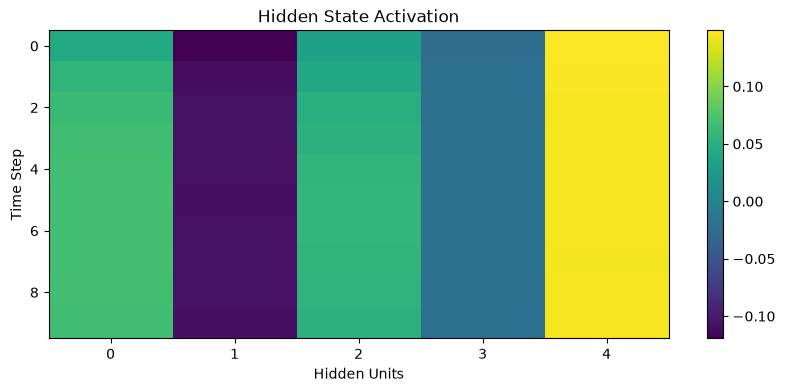

In [13]:
import matplotlib.pyplot as plt

model = RecurrentModel("LSTM")

output = model(x)

hidden = output.detach().numpy()[0]

plt.figure(figsize=(10,4))

plt.imshow(hidden, aspect="auto", cmap="viridis")

plt.colorbar()

plt.title("Hidden State Activation")

plt.xlabel("Hidden Units")

plt.ylabel("Time Step")

plt.show()

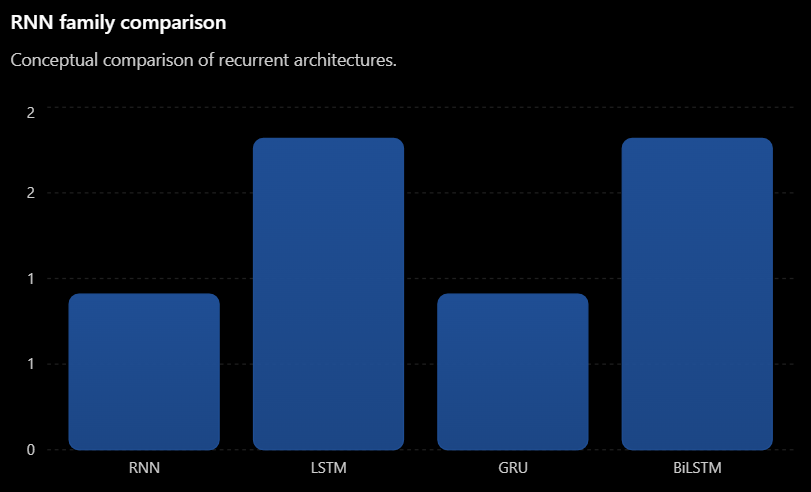